In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [ ]:
import os

base_path = "C:/Users/pc/Desktop/Emotion_detector/drowsiness_detection/dataset"

print("Datasets available in Kaggle:")
for item in os.listdir(base_path):
    print(item)

Datasets available in Kaggle:
datasets


In [ ]:
dataset_path = "C:/Users/pc/Desktop/Emotion_detector/drowsiness_detection/dataset/train"

print("Contents of dataset folder:")

for item in os.listdir(dataset_path):
    print(item)

Contents of dataset folder:
Closed
Open
yawn
no_yawn


In [4]:
import os

classes = ["Closed", "Open", "yawn", "no_yawn"]

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    
    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    
    print(f"{class_name}: {len(images)} images")

Closed: 726 images
Open: 726 images
yawn: 723 images
no_yawn: 725 images


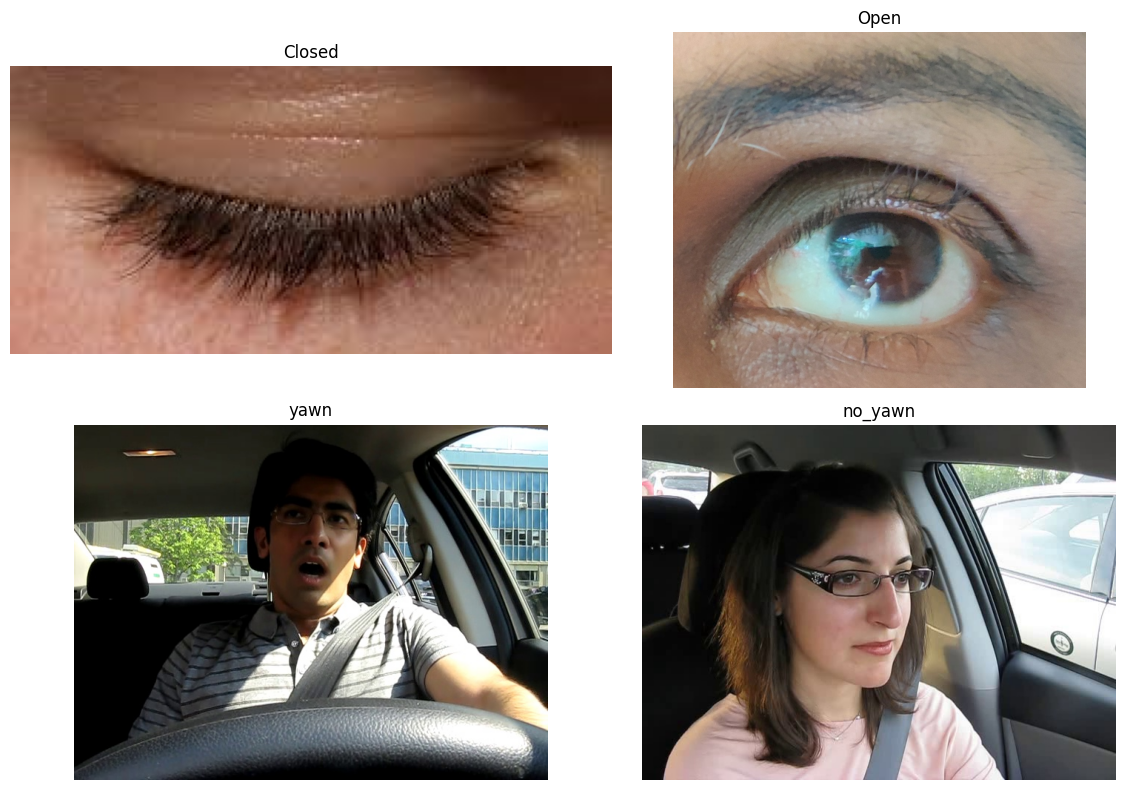

In [5]:
import random
from PIL import Image

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(dataset_path, class_name)
    
    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    
    image_name = random.choice(images)
    image_path = os.path.join(class_path, image_name)
    
    image = Image.open(image_path)
    
    plt.subplot(2, 2, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    
    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    
    image_path = os.path.join(class_path, images[0])
    
    image = Image.open(image_path)
    
    print(f"{class_name}: {image.size}")

Closed: (223, 223)
Open: (711, 712)
yawn: (640, 480)
no_yawn: (640, 480)


In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)

validation_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

print("\nClass indices:")
print(train_generator.class_indices)

Found 2321 images belonging to 4 classes.
Found 579 images belonging to 4 classes.

Class indices:
{'Closed': 0, 'Open': 1, 'no_yawn': 2, 'yawn': 3}


In [8]:
images, labels = next(train_generator)

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print("\nFirst 10 labels:")
print(np.argmax(labels[:10], axis=1))

print("\nClass mapping:")
print(train_generator.class_indices)


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 4)

First 10 labels:
[2 2 0 1 0 1 2 0 0 2]

Class mapping:
{'Closed': 0, 'Open': 1, 'no_yawn': 2, 'yawn': 3}


In [9]:
from tensorflow.keras import Sequential
from tensorflow.keras import layers

model = Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(4, activation="softmax")
])

model.summary()

I0000 00:00:1789307162.074726      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789307162.077600      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,828 (1.61 MB)

 Trainable params: 421,828 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [11]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint(
    "best_drowsiness_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks = [
    checkpoint,
    early_stopping,
    reduce_lr
]

print("Callbacks created successfully.")

Callbacks created successfully.


In [12]:
EPOCHS = 50

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/50
 2/73 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.3125 - loss: 1.3603 

I0000 00:00:1789307172.974449     147 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.3833 - loss: 1.1624
Epoch 1: val_accuracy improved from None to 0.50086, saving model to best_drowsiness_model.keras

Epoch 1: finished saving model to best_drowsiness_model.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 34s 352ms/step - accuracy: 0.4533 - loss: 0.9876 - val_accuracy: 0.5009 - val_loss: 0.7280 - learning_rate: 0.0010
Epoch 2/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.5290 - loss: 0.7488
Epoch 2: val_accuracy improved from 0.50086 to 0.54231, saving model to best_drowsiness_model.keras

Epoch 2: finished saving model to best_drowsiness_model.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 128ms/step - accuracy: 0.5325 - loss: 0.7379 - val_accuracy: 0.5423 - val_loss: 0.6920 - learning_rate: 0.0010
Epoch 3/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.5072 - loss: 0.7163
Epoch 3: val_accuracy improved from 0.54231 to 0.55613, saving model to best_drowsiness_model.keras

Epoch 3: finished saving model to best_drowsin

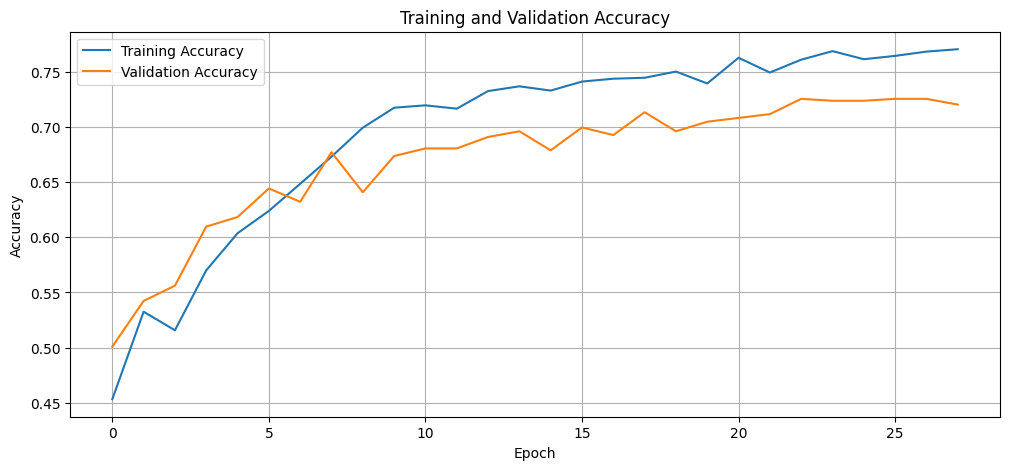

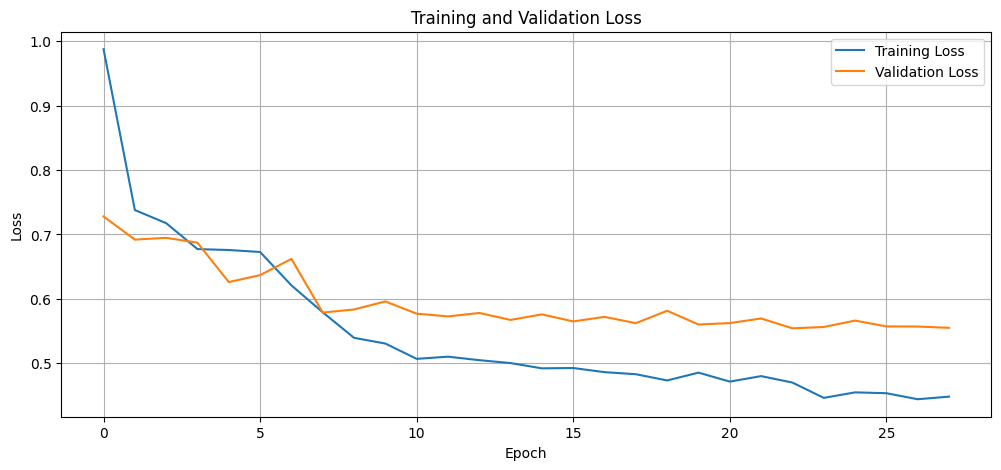

In [13]:
plt.figure(figsize=(12, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()


plt.figure(figsize=(12, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step
Classification Report:

              precision    recall  f1-score   support

      Closed       0.86      0.91      0.88       145
        Open       0.90      0.85      0.88       145
     no_yawn       0.58      0.50      0.54       145
        yawn       0.56      0.64      0.60       144

    accuracy                           0.73       579
   macro avg       0.73      0.73      0.72       579
weighted avg       0.73      0.73      0.72       579



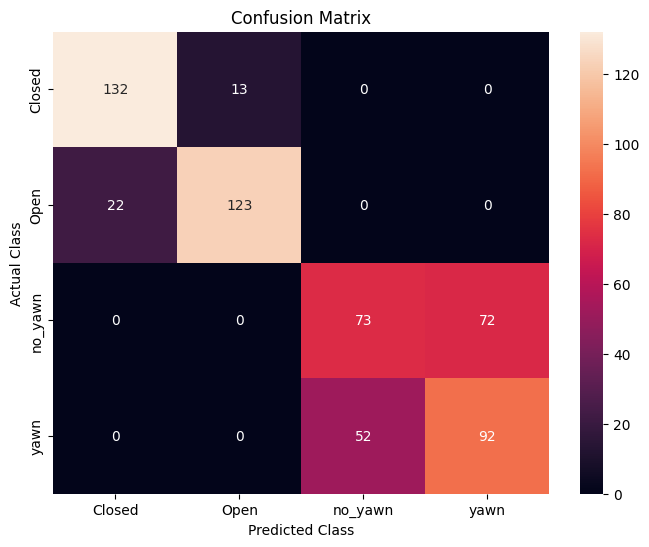

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

validation_generator.reset()

predictions = model.predict(validation_generator)

y_pred = np.argmax(predictions, axis=1)

y_true = validation_generator.classes

class_names = list(validation_generator.class_indices.keys())

print("Classification Report:\n")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [15]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest",
    validation_split=0.2
)

validation_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)

validation_generator = validation_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42
)

print("Training images:", train_generator.samples)
print("Validation images:", validation_generator.samples)
print("Classes:", train_generator.class_indices)

Found 2321 images belonging to 4 classes.
Found 579 images belonging to 4 classes.
Training images: 2321
Validation images: 579
Classes: {'Closed': 0, 'Open': 1, 'no_yawn': 2, 'yawn': 3}


In [16]:
model_aug = Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(4, activation="softmax")
])

model_aug.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,828 (1.61 MB)

 Trainable params: 421,828 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model_aug.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Augmented model compiled successfully.")

Augmented model compiled successfully.


In [18]:
checkpoint_aug = ModelCheckpoint(
    "best_drowsiness_aug.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stopping_aug = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_aug = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks_aug = [
    checkpoint_aug,
    early_stopping_aug,
    reduce_lr_aug
]

print("Augmented model callbacks created successfully.")

Augmented model callbacks created successfully.


In [19]:
EPOCHS = 50

history_aug = model_aug.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=callbacks_aug
)

Epoch 1/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.3290 - loss: 1.2585
Epoch 1: val_accuracy improved from None to 0.54922, saving model to best_drowsiness_aug.keras

Epoch 1: finished saving model to best_drowsiness_aug.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 41s 507ms/step - accuracy: 0.4140 - loss: 1.0810 - val_accuracy: 0.5492 - val_loss: 0.7467 - learning_rate: 0.0010
Epoch 2/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.5370 - loss: 0.7657
Epoch 2: val_accuracy improved from 0.54922 to 0.58377, saving model to best_drowsiness_aug.keras

Epoch 2: finished saving model to best_drowsiness_aug.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 34s 461ms/step - accuracy: 0.5614 - loss: 0.7290 - val_accuracy: 0.5838 - val_loss: 0.6669 - learning_rate: 0.0010
Epoch 3/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.6180 - loss: 0.6721
Epoch 3: val_accuracy improved from 0.58377 to 0.64594, saving model to best_drowsiness_aug.keras

Epoch 3: finished saving model to best_drows

In [20]:
best_model = tf.keras.models.load_model("best_drowsiness_aug.keras")

print("Best model loaded successfully.")

loss, accuracy = best_model.evaluate(
    validation_generator,
    verbose=1
)

print(f"\nValidation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

Best model loaded successfully.
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 161ms/step - accuracy: 0.8117 - loss: 0.4328

Validation Loss: 0.4328
Validation Accuracy: 0.8117


19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step
Classification Report:

              precision    recall  f1-score   support

      Closed     0.8684    0.9103    0.8889       145
        Open     0.9058    0.8621    0.8834       145
     no_yawn     0.7347    0.7448    0.7397       145
        yawn     0.7394    0.7292    0.7343       144

    accuracy                         0.8117       579
   macro avg     0.8121    0.8116    0.8116       579
weighted avg     0.8122    0.8117    0.8117       579



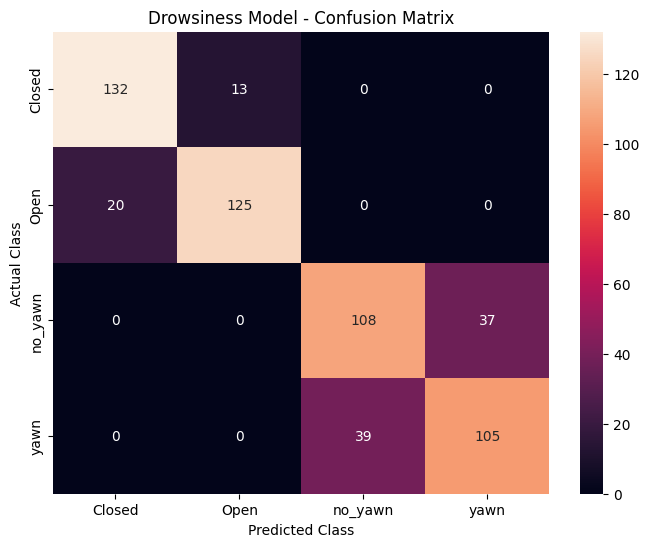

In [21]:
validation_generator.reset()

predictions = best_model.predict(validation_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = validation_generator.classes

class_names = list(validation_generator.class_indices.keys())

print("Classification Report:\n")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Drowsiness Model - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [22]:
from tensorflow.keras.utils import load_img, img_to_array

class_names = ["Closed", "Open", "no_yawn", "yawn"]

def predict_drowsiness(image_path):
    image = load_img(image_path, target_size=(224, 224))
    image_array = img_to_array(image)
    image_array = image_array / 255.0
    image_array = np.expand_dims(image_array, axis=0)

    prediction = best_model.predict(image_array, verbose=0)

    predicted_index = np.argmax(prediction[0])
    predicted_class = class_names[predicted_index]
    confidence = prediction[0][predicted_index] * 100

    print("Predicted Class:", predicted_class)
    print(f"Confidence: {confidence:.2f}%")

    return predicted_class, confidence

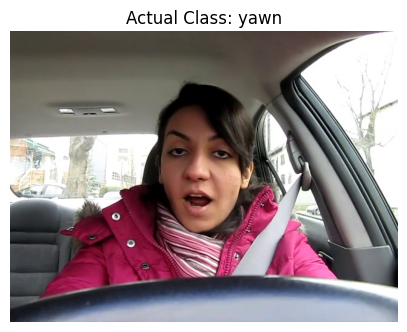

Predicted Class: yawn
Confidence: 98.70%

Actual Class: yawn
Predicted Class: yawn
Confidence: 98.70%


In [23]:
import random
from PIL import Image

actual_class = random.choice(class_names)

class_path = os.path.join(dataset_path, actual_class)

image_files = [
    f for f in os.listdir(class_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

image_name = random.choice(image_files)
image_path = os.path.join(class_path, image_name)

image = Image.open(image_path)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(f"Actual Class: {actual_class}")
plt.axis("off")
plt.show()

predicted_class, confidence = predict_drowsiness(image_path)

print(f"\nActual Class: {actual_class}")
print(f"Predicted Class: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")

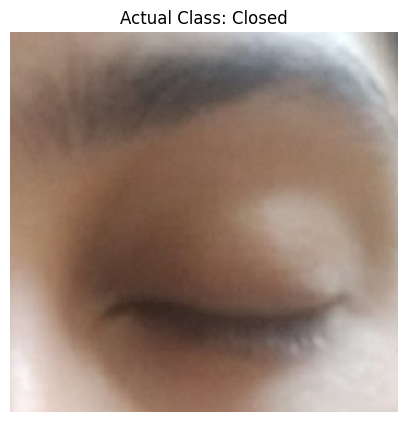

Predicted Class: Closed
Confidence: 99.48%

Actual Class: Closed
Predicted Class: Closed
Confidence: 99.48%


In [24]:
actual_class = "Closed"

class_path = os.path.join(dataset_path, actual_class)

image_files = [
    f for f in os.listdir(class_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

image_name = random.choice(image_files)
image_path = os.path.join(class_path, image_name)

image = Image.open(image_path)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title("Actual Class: Closed")
plt.axis("off")
plt.show()

predicted_class, confidence = predict_drowsiness(image_path)

print(f"\nActual Class: {actual_class}")
print(f"Predicted Class: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")

In [25]:
import random

correct = 0
total = 20

results = []

for i in range(total):
    actual_class = random.choice(class_names)

    class_path = os.path.join(dataset_path, actual_class)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_name = random.choice(image_files)
    image_path = os.path.join(class_path, image_name)

    predicted_class, confidence = predict_drowsiness(image_path)

    is_correct = predicted_class == actual_class

    if is_correct:
        correct += 1

    results.append({
        "Actual": actual_class,
        "Predicted": predicted_class,
        "Confidence": confidence,
        "Correct": is_correct
    })

    print(
        f"{i+1:02d}. "
        f"Actual: {actual_class:8s} | "
        f"Predicted: {predicted_class:8s} | "
        f"Confidence: {confidence:.2f}% | "
        f"{'Correct' if is_correct else 'Wrong'}"
    )

print("\n" + "=" * 60)
print(f"Correct Predictions: {correct}/{total}")
print(f"Test Accuracy: {(correct / total) * 100:.2f}%")
print("=" * 60)

Predicted Class: yawn
Confidence: 100.00%
01. Actual: yawn     | Predicted: yawn     | Confidence: 100.00% | Correct
Predicted Class: Closed
Confidence: 71.74%
02. Actual: Closed   | Predicted: Closed   | Confidence: 71.74% | Correct
Predicted Class: Open
Confidence: 93.17%
03. Actual: Open     | Predicted: Open     | Confidence: 93.17% | Correct
Predicted Class: Open
Confidence: 85.30%
04. Actual: Open     | Predicted: Open     | Confidence: 85.30% | Correct
Predicted Class: Open
Confidence: 64.75%
05. Actual: Open     | Predicted: Open     | Confidence: 64.75% | Correct
Predicted Class: no_yawn
Confidence: 56.01%
06. Actual: no_yawn  | Predicted: no_yawn  | Confidence: 56.01% | Correct
Predicted Class: Closed
Confidence: 99.40%
07. Actual: Closed   | Predicted: Closed   | Confidence: 99.40% | Correct
Predicted Class: Open
Confidence: 99.36%
08. Actual: Open     | Predicted: Open     | Confidence: 99.36% | Correct
Predicted Class: no_yawn
Confidence: 54.96%
09. Actual: no_yawn  | Pred

In [26]:
best_model.save("drowsiness_model.keras")

DROWSINESS_MAP = {
    "Closed": "Sleeping",
    "Open": "Awake",
    "no_yawn": "Awake",
    "yawn": "Sleeping"
}

print("Final model saved successfully.")
print("File: drowsiness_model.keras")

print("\nDrowsiness mapping:")
for class_name, state in DROWSINESS_MAP.items():
    print(f"{class_name} -> {state}")

Final model saved successfully.
File: drowsiness_model.keras

Drowsiness mapping:
Closed -> Sleeping
Open -> Awake
no_yawn -> Awake
yawn -> Sleeping


In [27]:
import os

model_file = "drowsiness_model.keras"

if os.path.exists(model_file):
    file_size = os.path.getsize(model_file) / (1024 * 1024)

    print("Model file found.")
    print("File name:", model_file)
    print(f"File size: {file_size:.2f} MB")
else:
    print("Model file not found.")

Model file found.
File name: drowsiness_model.keras
File size: 4.88 MB
